In [1]:
import warnings


warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
from pm4py.objects.conversion.log import converter as log_converter


DATASET_LIST = [
    'BPIC_13_C',
    'BPIC_13_I',
    'BPIC_20_DD',
    'BPIC_20_ID',
    'BPIC_20_PTC',
    'BPIC_20_RFP',
    'BPIC_20_TPD',
    'Helpdesk',
]

In [2]:
def load_log(path: str):
    log_df = pm4py.read_xes(path)
    log = log_converter.apply(log_df)
    return log, log_df


def get_unique_events(log_df: pd.DataFrame):
    return sorted(log_df['concept:name'].unique())


def get_trace_length(log_df: pd.DataFrame):
    trace_lengths = log_df.groupby('case:concept:name').size()
    return trace_lengths.tolist()


def get_trace_duration(log_df: pd.DataFrame):
    trace_durations = log_df.groupby('case:concept:name')['time:timestamp'].agg(
        ['min', 'max']
    )
    trace_durations['duration'] = (
        trace_durations['max'] - trace_durations['min']
    ).dt.total_seconds()
    return trace_durations['duration'].tolist()


def get_start_events(log_df: pd.DataFrame):
    start_events = log_df.groupby('case:concept:name').first()['concept:name']
    return start_events.value_counts().to_dict()


def get_end_events(log_df: pd.DataFrame):
    end_events = log_df.groupby('case:concept:name').last()['concept:name']
    return end_events.value_counts().to_dict()

## Dataset Analysis

In [3]:
def get_trace_length_distribution(log_df: pd.DataFrame, dataset_name: str):
    lengths = get_trace_length(log_df)

    plt.figure(figsize=(10, 6))
    plt.hist(
        lengths,
        bins=range(min(lengths), max(lengths) + 2),
        color='skyblue',
        edgecolor='black',
        alpha=0.7,
    )

    percentiles = [
        {
            'label': '80% Percentile',
            'value': np.percentile(lengths, 80),
            'color': 'red',
            'linestyle': 'dashed',
        },
        {
            'label': '90% Percentile',
            'value': np.percentile(lengths, 90),
            'color': 'orange',
            'linestyle': 'dashed',
        },
        {
            'label': '95% Percentile',
            'value': np.percentile(lengths, 95),
            'color': 'purple',
            'linestyle': 'dashed',
        },
        {
            'label': 'Median',
            'value': np.median(lengths),
            'color': 'green',
            'linestyle': 'dotted',
        },
    ]

    for p in percentiles:
        plt.axvline(
            p['value'],
            color=p['color'],
            linestyle=p['linestyle'],
            linewidth=2,
            label=f'{p["label"]} ({int(p["value"])})',
        )

    plt.title(f'Trace Length Distribution: {dataset_name}')
    plt.xlabel('Number of Events (Trace Length)')
    plt.ylabel('Frequency (Number of Traces)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


def get_trace_duration_distribution(log_df: pd.DataFrame, dataset_name: str):
    durations = get_trace_duration(log_df)

    plt.figure(figsize=(10, 6))
    plt.hist(
        durations,
        bins=10,
        color='lightcoral',
        edgecolor='black',
        alpha=0.7,
    )

    percentiles = [
        {
            'label': '80% Percentile',
            'value': np.percentile(durations, 80),
            'color': 'red',
            'linestyle': 'dashed',
        },
        {
            'label': '90% Percentile',
            'value': np.percentile(durations, 90),
            'color': 'orange',
            'linestyle': 'dashed',
        },
        {
            'label': '95% Percentile',
            'value': np.percentile(durations, 95),
            'color': 'purple',
            'linestyle': 'dashed',
        },
        {
            'label': 'Median',
            'value': np.median(durations),
            'color': 'green',
            'linestyle': 'dotted',
        },
    ]

    for p in percentiles:
        plt.axvline(
            p['value'],
            color=p['color'],
            linestyle=p['linestyle'],
            linewidth=2,
            label=f'{p["label"]} ({int(p["value"]):,}s)',
        )

    plt.title(f'Trace Duration Distribution: {dataset_name}')
    plt.xlabel('Duration (Seconds)')
    plt.ylabel('Frequency (Number of Traces)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [4]:
for dataset_name in DATASET_LIST:
    dataset_path = (
        f'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/{dataset_name}.xes'
    )

    log, log_df = load_log(dataset_path)

    unique_events = get_unique_events(log_df)

    print(f'Dataset: {dataset_name}')
    print(f'Number of unique events: {len(unique_events)}')
    print(f'Unique events: {unique_events}')
    print(f'End events: {get_end_events(log_df)}')
    print(f'Number of events: {len(log_df)}')
    print(f'Number of traces: {log_df["case:concept:name"].nunique()}')
    print('================================')

c:\Users\Pavel\Desktop\PROJECTS\master-thesis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 3736.65it/s]


Dataset: BPIC_13_C
Number of unique events: 4
Unique events: ['Accepted', 'Completed', 'Queued', 'Unmatched']
End events: {'Completed': 1487}
Number of events: 6660
Number of traces: 1487


parsing log, completed traces :: 100%|██████████| 7554/7554 [00:03<00:00, 2075.24it/s]


Dataset: BPIC_13_I
Number of unique events: 4
Unique events: ['Accepted', 'Completed', 'Queued', 'Unmatched']
End events: {'Completed': 7546, 'Accepted': 8}
Number of events: 65533
Number of traces: 7554


parsing log, completed traces :: 100%|██████████| 10500/10500 [00:01<00:00, 6710.35it/s]


...

Dataset: BPIC_20_RFP
Number of unique events: 19
Unique events: ['Payment Handled', 'Request For Payment APPROVED by ADMINISTRATION', 'Request For Payment APPROVED by BUDGET OWNER', 'Request For Payment APPROVED by PRE_APPROVER', 'Request For Payment APPROVED by SUPERVISOR', 'Request For Payment FINAL_APPROVED by BUDGET OWNER', 'Request For Payment FINAL_APPROVED by DIRECTOR', 'Request For Payment FINAL_APPROVED by SUPERVISOR', 'Request For Payment FOR_APPROVAL by ADMINISTRATION', 'Request For Payment FOR_APPROVAL by SUPERVISOR', 'Request For Payment REJECTED by ADMINISTRATION', 'Request For Payment REJECTED by BUDGET OWNER', 'Request For Payment REJECTED by EMPLOYEE', 'Request For Payment REJECTED by MISSING', 'Request For Payment REJECTED by PRE_APPROVER', 'Request For Payment REJECTED by SUPERVISOR', 'Request For Payment SAVED by EMPLOYEE', 'Request For Payment SUBMITTED by EMPLOYEE', 'Request Payment']
End events: {'Payment Handled': 6305, 'Request For Payment REJECTED by EMPLOYEE'

parsing log, completed traces :: 100%|██████████| 7065/7065 [00:02<00:00, 2948.60it/s]


Dataset: BPIC_20_TPD
Number of unique events: 51
Unique events: ['Declaration APPROVED by ADMINISTRATION', 'Declaration APPROVED by BUDGET OWNER', 'Declaration APPROVED by PRE_APPROVER', 'Declaration APPROVED by SUPERVISOR', 'Declaration FINAL_APPROVED by DIRECTOR', 'Declaration FINAL_APPROVED by SUPERVISOR', 'Declaration REJECTED by ADMINISTRATION', 'Declaration REJECTED by BUDGET OWNER', 'Declaration REJECTED by DIRECTOR', 'Declaration REJECTED by EMPLOYEE', 'Declaration REJECTED by MISSING', 'Declaration REJECTED by PRE_APPROVER', 'Declaration REJECTED by SUPERVISOR', 'Declaration SAVED by EMPLOYEE', 'Declaration SUBMITTED by EMPLOYEE', 'End trip', 'Payment Handled', 'Permit APPROVED by ADMINISTRATION', 'Permit APPROVED by BUDGET OWNER', 'Permit APPROVED by PRE_APPROVER', 'Permit APPROVED by SUPERVISOR', 'Permit FINAL_APPROVED by DIRECTOR', 'Permit FINAL_APPROVED by SUPERVISOR', 'Permit FOR_APPROVAL by ADMINISTRATION', 'Permit FOR_APPROVAL by SUPERVISOR', 'Permit REJECTED by ADMINIS

parsing log, completed traces :: 100%|██████████| 4580/4580 [00:02<00:00, 2158.84it/s]


Dataset: Helpdesk
Number of unique events: 14
Unique events: ['Assign seriousness', 'Closed', 'Create SW anomaly', 'DUPLICATE', 'INVALID', 'Insert ticket', 'RESOLVED', 'Require upgrade', 'Resolve SW anomaly', 'Resolve ticket', 'Schedule intervention', 'Take in charge ticket', 'VERIFIED', 'Wait']
End events: {'Closed': 4557, 'Resolve ticket': 10, 'Wait': 8, 'Require upgrade': 3, 'VERIFIED': 1, 'Take in charge ticket': 1}
Number of events: 21348
Number of traces: 4580


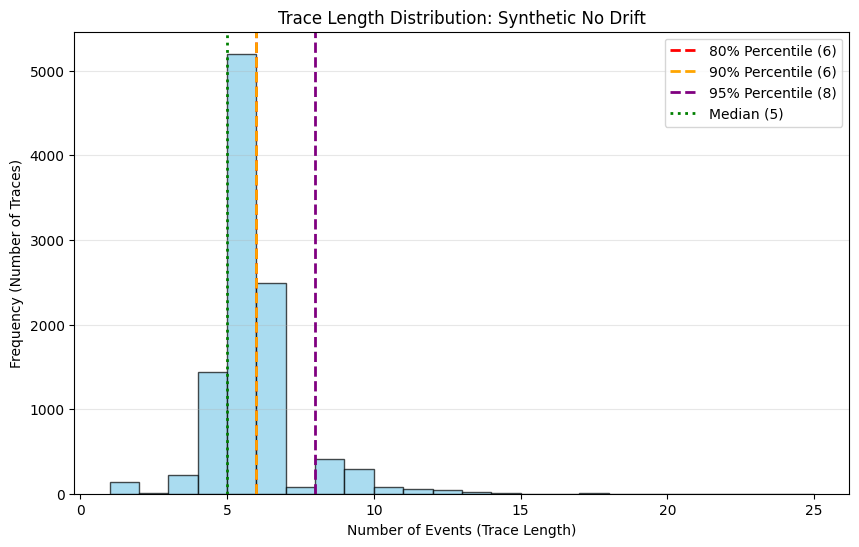

In [23]:
get_trace_length_distribution(log_df, dataset_name)

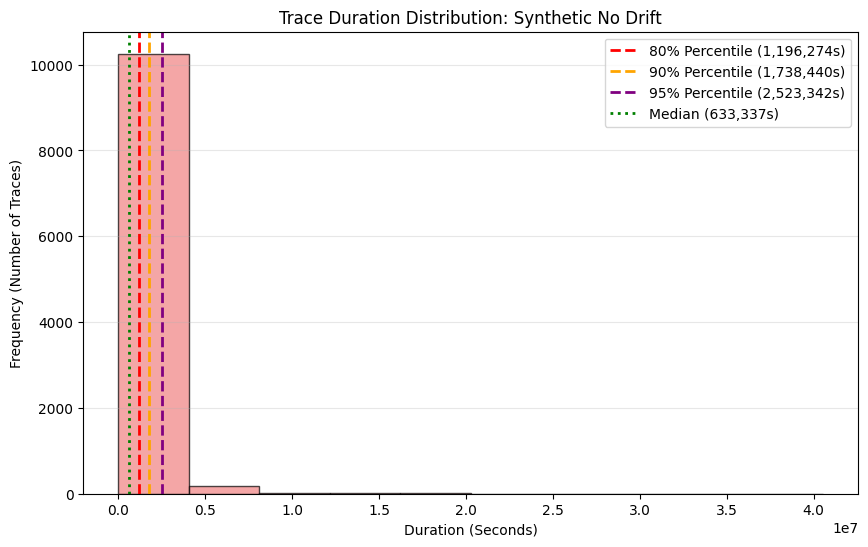

In [24]:
get_trace_duration_distribution(log_df, dataset_name)

In [25]:
print(f'Start events: {get_start_events(log_df)}')
print(f'End events: {get_end_events(log_df)}')

Start events: {'Declaration SUBMITTED by EMPLOYEE': 10365, 'Declaration SAVED by EMPLOYEE': 135}
End events: {'Payment Handled': 10043, 'Declaration REJECTED by EMPLOYEE': 284, 'Declaration SAVED by EMPLOYEE': 134, 'Declaration REJECTED by MISSING': 30, 'Declaration REJECTED by ADMINISTRATION': 5, 'Declaration REJECTED by SUPERVISOR': 4}


In [11]:
unique_events = get_unique_events(log_df)
print(len(unique_events))
print(unique_events)

17
['Declaration APPROVED by ADMINISTRATION', 'Declaration APPROVED by BUDGET OWNER', 'Declaration APPROVED by PRE_APPROVER', 'Declaration FINAL_APPROVED by SUPERVISOR', 'Declaration FOR_APPROVAL by ADMINISTRATION', 'Declaration FOR_APPROVAL by PRE_APPROVER', 'Declaration FOR_APPROVAL by SUPERVISOR', 'Declaration REJECTED by ADMINISTRATION', 'Declaration REJECTED by BUDGET OWNER', 'Declaration REJECTED by EMPLOYEE', 'Declaration REJECTED by MISSING', 'Declaration REJECTED by PRE_APPROVER', 'Declaration REJECTED by SUPERVISOR', 'Declaration SAVED by EMPLOYEE', 'Declaration SUBMITTED by EMPLOYEE', 'Payment Handled', 'Request Payment']


In [ ]:
def get_events_number(log_df: pd.DataFrame):
    return log_df.shape[0]

def get_cases_number(log_df: pd.DataFrame):
    return log_df['case:concept:name'].nunique()

In [18]:
events_number = get_events_number(log_df)
cases_number = get_cases_number(log_df)
preds_number = events_number - cases_number

print('Events:', events_number)
print('Cases:', cases_number)
print('Predictions:', preds_number)

Events: 56437
Cases: 10500
Predictions: 45937


In [4]:
def sample_complete_traces_and_save_xes(
    log_df: pd.DataFrame,
    output_path: str,
    fraction: float | None = None,
    n_cases: int | None = None,
    random_state: int = 42,
):
    case_col = 'case:concept:name'
    time_col = 'time:timestamp'

    if (fraction is None) == (n_cases is None):
        raise ValueError('Set exactly one of: fraction or n_cases.')

    case_ids = log_df[case_col].dropna().unique()
    total_cases = len(case_ids)

    if fraction is not None:
        if not (0 < fraction <= 1):
            raise ValueError('fraction must be in (0, 1].')
        k = max(1, int(round(total_cases * fraction)))
    else:
        if n_cases <= 0:
            raise ValueError('n_cases must be > 0.')
        k = min(n_cases, total_cases)

    rng = np.random.default_rng(random_state)
    sampled_case_ids = rng.choice(case_ids, size=k, replace=False)

    # keep full traces (all events for selected cases)
    sampled_df = log_df[log_df[case_col].isin(sampled_case_ids)].copy()

    # stable ordering (recommended before export)
    sort_cols = [case_col] + ([time_col] if time_col in sampled_df.columns else [])
    sampled_df = sampled_df.sort_values(sort_cols)

    # DataFrame -> EventLog -> XES
    sampled_log = log_converter.apply(sampled_df)
    pm4py.write_xes(sampled_log, output_path)

    print(f'Saved: {output_path}')
    print(f'Cases: {k}/{total_cases}')
    print(f'Events: {len(sampled_df)}')

    return sampled_df

In [8]:
small_df = sample_complete_traces_and_save_xes(
    log_df=log_df,
    output_path='C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/BPIC_20_DD_small.xes',
    fraction=0.10,
    # n_cases=500,
    random_state=42,
)

Saved: C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/BPIC_20_DD_small.xes
Cases: 1050/10500
Events: 5711


## DARWIN

In [3]:
def get_hyperparam_search_size(
    log_df: pd.DataFrame,
    max_events_rate: float = 0.1,
    init_size_rate: float = 0.8,
    case_id_col: str = 'case:concept:name',
):
    total_events = len(log_df)
    total_cases = log_df[case_id_col].nunique()

    max_events = math.ceil(total_events * max_events_rate)

    raw_init_boundary = math.floor(max_events * init_size_rate)

    # A trace 'ends' if its next event is not in this slice or doesn't exist
    # Count how many unique Case IDs have their absolute final event inside interval
    global_last_indices = log_df.groupby(case_id_col).tail(1).index
    ended_cases_num = len([idx for idx in global_last_indices if idx < raw_init_boundary])

    # Final calculation: Events in window minus those that have no 'next activity'
    init_size = raw_init_boundary - ended_cases_num

    return {
        'total_events': total_events,
        'total_cases': total_cases,
        'max_events': max_events,
        'init_size': init_size,
        'val_size': max_events - raw_init_boundary,
        'ended_cases': ended_cases_num,
    }

In [4]:
for dataset_name in DATASET_LIST:
    dataset_path = (
        f'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/{dataset_name}.xes'
    )

    log, log_df = load_log(dataset_path)

    print(f'Dataset: {dataset_name}')

    hyperparam_search_size = get_hyperparam_search_size(log_df)
    print(f'{hyperparam_search_size}')
    print('================================')


Dataset: BPIC_13_C
{'total_events': 6660, 'total_cases': 1487, 'max_events': 666, 'init_size': 440, 'val_size': 134, 'ended_cases': 92}
Dataset: BPIC_13_I
{'total_events': 65533, 'total_cases': 7554, 'max_events': 6554, 'init_size': 4962, 'val_size': 1311, 'ended_cases': 281}
Dataset: BPIC_20_DD
{'total_events': 56437, 'total_cases': 10500, 'max_events': 5644, 'init_size': 3521, 'val_size': 1129, 'ended_cases': 994}
Dataset: BPIC_20_ID
{'total_events': 72151, 'total_cases': 6449, 'max_events': 7216, 'init_size': 5133, 'val_size': 1444, 'ended_cases': 639}
Dataset: BPIC_20_PTC
{'total_events': 18246, 'total_cases': 2099, 'max_events': 1825, 'init_size': 1275, 'val_size': 365, 'ended_cases': 185}
Dataset: BPIC_20_RFP
{'total_events': 36796, 'total_cases': 6886, 'max_events': 3680, 'init_size': 2291, 'val_size': 736, 'ended_cases': 653}
Dataset: BPIC_20_TPD
{'total_events': 86581, 'total_cases': 7065, 'max_events': 8659, 'init_size': 6272, 'val_size': 1732, 'ended_cases': 655}
Dataset: He